# Evaluation

In [1]:
import sys
import os

# Add parent directory to path so we can import DatasetLoader
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
from DatasetLoader import cub_v2 as cub
from DatasetLoader import CXR as cxr
import NetworkManager

/home/matteo/miniforge3/envs/mambaLRPTEST/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
DEFAULT_BATCH_SIZE   = 1
DEFAULT_IMG_SIZE     = 448
#dummy values since we are not training
DEFAULT_BASE_LR      = 5e-5
DEFAULT_EPOCHS       = 95
DEFAULT_MOMENTUM     = 0.9
DEFAULT_WEIGHT_DECAY = 1e-4
DEFAULT_GPU_ID       = 0


MODEL_CHOICES        = ['vit_base_patch16_224']

net_options = {
    'net_choice': "Transformer",
    'model_choice': MODEL_CHOICES[0],
    'epochs': DEFAULT_EPOCHS,
    'batch_size': DEFAULT_BATCH_SIZE,
    'base_lr': DEFAULT_BASE_LR,
    'weight_decay': DEFAULT_WEIGHT_DECAY,
    'momentum': DEFAULT_MOMENTUM,
    'img_size': DEFAULT_IMG_SIZE,
    'device': torch.device('cuda:'+str(DEFAULT_GPU_ID) if torch.cuda.is_available() else 'cpu'),
    'model_type': MODEL_CHOICES[0],
    'save_folder_path': './model_save'
}


cxr_dataset_options = cxr.dataset_options
cub_dataset_options = cub.dataset_options

In [3]:
# --------------------- EDIT THIS TO CHANGE DATASET --------------------- #
DATASET = "cxr"

In [4]:
if DATASET == "cxr":
    train_loader, test_loader = cxr.get_dataloaders(batchsize=DEFAULT_BATCH_SIZE, data_dir=cxr_dataset_options['data_root'], img_size=net_options['img_size'])
    dataset_options = cxr_dataset_options
elif DATASET == "cub":
    train_loader, test_loader = cub.get_dataloaders(batch_size=DEFAULT_BATCH_SIZE,
                                             root=cub_dataset_options['data_root'],
                                             img_size=net_options['img_size'])
    dataset_options = cub_dataset_options

print("OPTIONS VALUES")
print(dataset_options)

manager = NetworkManager.NetworkManager(net_options, dataset_options, train_loader, test_loader, mode='train', checkpoint_path=f'./model_save/{DATASET}/vit_base_patch16_224_Unfrozen.pkl')

OPTIONS VALUES
{'name': 'CXR', 'data_root': '../CXR/', 'n_class': 3}
Starting to prepare network and data...
Loading checkpoint from ./model_save/cxr/vit_base_patch16_224_Unfrozen.pkl...
Network is as follows:
DataParallel(
  (module): TransformerModule(
    (vit): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_dro

In [5]:
stats = manager.evaluate_detailed()


--- Detailed Evaluation ---
--- Performance results ---
Accuracy: 0.8131
Precision (Macro Avg): 0.8116
Recall (Macro Avg): 0.8209
F1-Score (Macro Avg): 0.8127
AUC (Multi-class OVR): 0.8989


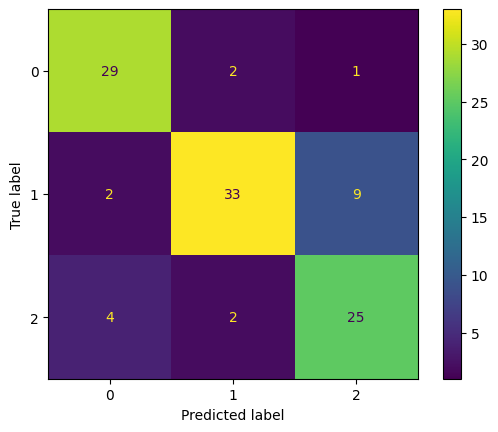

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
#show confusion matrix
disp = ConfusionMatrixDisplay(stats['confusion_matrix'])
disp.plot()

import matplotlib.pyplot as plt
plt.show()